In [1]:
%load_ext autoreload
%autoreload 2
from matplotlib import pyplot as plt
from matplotlib import pylab as pl
import numpy as np
import pandas as pd
# from matplotlib import cm

import cmcrameri.cm as cmc
from matplotlib import rcParams

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.io import loadmat
from matplotlib.colors import LogNorm

from statData import StatData

nu = 1.8e-5

In [2]:
def make_statlist(caseids, ids, case_info):
    time_window = [0,10]
    dirname = ''

    statlist = {}
    for id, case in zip(ids, caseids):
            casename = case.split('/')[0]
            cinf = case_info.loc[casename]
            stat_params = cinf.to_dict()
            fname = dirname+casename+'.txt'
            statlist[id] = StatData(fname, ustar=stat_params['ustar_mean'])
            # statlist[id] = StatData.PVstat(id, case, params=stat_params, dirname=dirname, 
            #                             time_index=1, time_window=time_window,
            #                             save_mean=False, read_save=True)
    
    return statlist

In [3]:
def plot_velocity(stats, ids, colors, linestyles=['-'], axs=[], 
                  labels=True, xlabel=True):
    if len(axs) == 0:
        fig, axs = plt.subplots(1,2,facecolor='w', dpi=180.0, 
                                tight_layout=True, figsize=(8,4))

    if len(linestyles) < len(ids):
        linestyles = [linestyles[0] for i in range(len(ids))]

    for i in range(len(ids)):
        id = ids[i]
        u = stats[id].data['U']
        y = stats[id].data['ym']

        print('U(150) for '+id.replace("\n","").ljust(30)+': {:.2f}'.format(stats[id].Uz(150)))

        if labels:
            axs[0].plot(u, y, lw=2, color=colors[i], ls=linestyles[i], 
                        label=id, zorder=1)
        else:
            axs[0].plot(u, y, lw=2, color=colors[i], ls=linestyles[i], zorder=1)
        
        # * viscous scaling
        ustar = stats[id].ustar
        H = 1000

        axs[1].plot(y[1:]/H, u[1:]/ustar, marker='.', ls=linestyles[i],
                    color=colors[i], label=id, zorder=1)


    # axs[0].axhline(150, color='gainsboro', label='Turbine Hub Height', zorder=0)
    # axs[1].axvline(150/H, color='gainsboro', zorder=0)

    axs[0].axhspan(30, 270, color='gainsboro', label='Example Turbine Rotor', zorder=0)
    axs[1].axvspan(30/H, 270/H, color='gainsboro', zorder=0)

    axs[0].set_ylim((0,500))
    axs[0].set_xlim((10,18))
    if xlabel:
        axs[0].set_xlabel('U (m/s)')
    axs[0].set_ylabel('z (m)')
    axs[0].legend(loc='upper left', labelspacing=0.7)

    axs[1].set_ylabel(r'$\langle \overline{u}\rangle/u_\ast$')
    if xlabel:
        axs[1].set_xlabel(r'$z/H$')
    axs[1].set_xscale('log')
    axs[1].set_xlim((1e-3, 1))

    # return fig, axs

In [4]:
def plot_reynolds(stats, ids, colors, linestyles=['-'], fig=None, axs=None, labels=True):
    if not fig:
        fig, axs = plt.subplots(2, 3, facecolor='w', dpi=180, constrained_layout=True,
                                figsize=(10,6), sharey=True)

    plot_ids = ['up_up','vp_vp','wp_wp','up_vp','up_wp','vp_wp']
    plot_labels = [r"$\langle u'u'\rangle$", r"$\langle v'v'\rangle$",
                r"$\langle w'w'\rangle$", r"$\langle u'v'\rangle$",
                r"$\langle u'w'\rangle$", r"$\langle v'w'\rangle$"]


    for j in range(len(plot_ids)):
        axi = int(j/3)
        axj = j%3

        ax = axs[axi,axj]

        for i in range(len(ids)):
            id = ids[i]

            if labels:
                ax.plot(stats[id].data[plot_ids[j]],stats[id].data['ym'],
                        lw=1.2, color=colors[i], ls=linestyles[i], label=id)
            else:
                ax.plot(stats[id].data[plot_ids[j]],stats[id].data['ym'],
                    lw=1.2, color=colors[i], ls=linestyles[i])
            
        ax.axhspan(30, 270, color='gainsboro', label='Example Turbine Rotor', zorder=0)
            
        if axj == 0:   
            ax.set_ylabel(r'$y$')
        ax.set_title(plot_labels[j])
        
        ax.set_ylim((0,1000))

    axs[0,0].legend()


In [5]:
def plot_upvp(stats, ids, colors, ax=False, labels=True, xlabel=True,
              linestyles=['-']):
    if not ax:
        fig, ax = plt.subplots(1,1, facecolor='w', dpi=180, figsize=(5.2,4.6))

    if len(linestyles) < len(ids):
        linestyles = [linestyles[0] for i in range(len(ids))]

    for i in range(len(ids)):
        id = ids[i]
        ax.plot(stats[id].data['up_vp'], stats[id].data['y'],
                lw=2, color=colors[i], linestyle=linestyles[i], label=id)

    # ax.axhline(150, color='gainsboro', zorder=0)
    ax.axhspan(30, 270, color='gainsboro', label='Example Turbine Rotor', zorder=0)
    
    if xlabel:
        ax.set_xlabel(r"$\langle u'w' \rangle$ (m$^2$/s$^2$)")
    ax.set_ylabel(r'$z$ (m)')
    
    ax.set_ylim((0,1000))

    if labels:
        ax.legend()

In [6]:
def plot_tke(stats, ids, colors, ax=False, labels=True, xlabel=True,
              linestyles=['-']):
    if not ax:
        fig, ax = plt.subplots(1,1, facecolor='w', dpi=180, figsize=(5.2,4.6))

    if len(linestyles) < len(ids):
        linestyles = [linestyles[0] for i in range(len(ids))]

    for i in range(len(ids)):
        id = ids[i]
        ax.plot(stats[id].data['tke'], stats[id].data['y'],
                lw=2, color=colors[i], linestyle=linestyles[i], label=id)

    # ax.axhline(150, color='gainsboro', zorder=0)
    ax.axhspan(30, 270, color='gainsboro', label='Example Turbine Rotor', zorder=0)
    
    if xlabel:
        ax.set_xlabel(r"$TKE$ (m$^2$/s$^2$)")
    ax.set_ylabel(r'$z$ (m)')
    
    ax.set_ylim((0,1000))

    if labels:
        ax.legend()

In [7]:
def coare_plot_starter(figsize, Romero_colorby='none', Romero_cmap='none'):

    # * COARE 3.5 formula
    ncoare = 500
    u10_coare = np.linspace(1,20,ncoare)
    ustar_coare = np.empty(ncoare)

    for i in range(ncoare):
        if u10_coare[i] < 4:
            ustar_coare[i] = 0.03 * u10_coare[i]
        elif u10_coare[i] < 9.6:
            ustar_coare[i] = 0.035 * u10_coare[i] - 0.005*4
        else:
            # ustar_coare[i] = 0.058 * u10_coare[i] - 0.24 # Andreas et al. (2012)
            ustar_coare[i] = 0.062 * u10_coare[i] - 0.28

    fig, ax = plt.subplots(1,1,facecolor='w', dpi=180.0,tight_layout=True, figsize=figsize)

    # * Edson
    # ed = edson.EdsonData()
    # ed.fill_outer_region(ax)
    # ed.fill_med_region(ax)
    # plt.plot(u10_coare,ustar_coare,'k',lw=2.5,label='COARE 3.5 (Edson et al. 2013)', zorder=2)

    ed = loadmat('experimental_data/TauDataEdson.mat')
    plt.scatter(ed['U10Nalex'], np.sqrt(ed['TAUalex']/1.2), s=8, marker='x', lw=0.5,
                color='darkgray', #color='gainsboro', 
                label='Edson et al. 2013', zorder=1)
    plt.plot(u10_coare,ustar_coare,'k',lw=2.5,label='COARE 3.5', zorder=2)

    # * Romero
    rom = pd.read_csv('experimental_data/romero_summary.csv', header=0, sep=' ',index_col=False)
    rom['hs'] = 4*np.sqrt(rom['eta_sq'])
    rom['kphs'] = rom['hs']*rom['kp']

    if Romero_colorby == 'none':
        ax.scatter(rom['U10'],rom['ustar'],c='black',
                   s=5,label='GOTEX',zorder=2)
    elif Romero_colorby == 'hs':
        rsc = ax.scatter(rom['U10'],rom['ustar'],c=rom['hs'],
                            cmap=Romero_cmap, vmin=0, vmax=4,
                            s=5,label='GOTEX',zorder=2)
        plt.colorbar(rsc, label=r'Romero $H_s$')
    elif Romero_colorby == 'kphs':
        rsc = ax.scatter(rom['U10'],rom['ustar'],c=rom['kphs'],
                            cmap=Romero_cmap, vmin=0, vmax=0.3,
                            s=5,label='GOTEX',zorder=2)
        plt.colorbar(rsc, label=r'$k_pH_s$')

    ax.set_xlabel(r'$U_{10}$ (m/s)')
    ax.set_ylabel(r'$u_*$ (m/s)')

    ax.legend()

    ax.set_xlim((0,21.0))
    ax.set_ylim((0,1.2))
    
    # ax.set_xlim((0,24.0))
    # ax.set_ylim((0,1.4))

    return fig, ax

    

In [10]:
def z0(U10, ustar):
    kappa = 0.4
    z0 = 10 / np.exp(U10*kappa/ustar)
    return z0

In [9]:
def coare_color_by_z0(ax, xlim, ylim):
    res = 100
    u10s = np.linspace(xlim[0],xlim[1],res)
    ustars = np.linspace(ylim[0],ylim[1],res)

    X, Y = np.meshgrid(u10s, ustars)
    Z = z0(X,Y)
    # levels = np.logspace(np.log10(Z.min()), np.log10(Z.max()), 10)
    levels = np.logspace(-8,1,10)

    if not ax:
        fig, ax = plt.subplots(1,1, facecolor='w', dpi=180.0,tight_layout=True,figsize=(6,5))
        plt.xlabel(r'$U_{10}$ (m/s)')
        plt.ylabel(r'$u_*$ (m/s)')

    contours = ax.contour(X, Y, Z, levels=levels, norm=LogNorm(), cmap=cmc.nuuk_r, zorder=0)
    cf = ax.contourf(X, Y, Z, levels=levels, norm=LogNorm(), cmap=cmc.nuuk_r, zorder=0)
    ax.clabel(contours, inline=True, fontsize=8, fmt="%.1e", colors='black')
    # fig.colorbar(cf, label=r"$z_0$", ticks=levels)

    # plt.xlabel(r'$U_{10}$ (m/s)')
    # plt.ylabel(r'$u_*$ (m/s)')

/tmp/ipykernel_1850313/4102278361.py:3: RuntimeWarning: divide by zero encountered in divide
  z0 = 10 / np.exp(U10*kappa/ustar)
/tmp/ipykernel_1850313/4102278361.py:3: RuntimeWarning: invalid value encountered in divide
  z0 = 10 / np.exp(U10*kappa/ustar)
/tmp/ipykernel_1850313/3166171445.py:16: UserWarning: Log scale: values of z <= 0 have been masked
  contours = ax.contour(X, Y, Z, levels=levels, norm=LogNorm(), cmap=cmc.nuuk_r, zorder=0)
/tmp/ipykernel_1850313/3166171445.py:17: UserWarning: Log scale: values of z <= 0 have been masked
  cf = ax.contourf(X, Y, Z, levels=levels, norm=LogNorm(), cmap=cmc.nuuk_r, zorder=0)


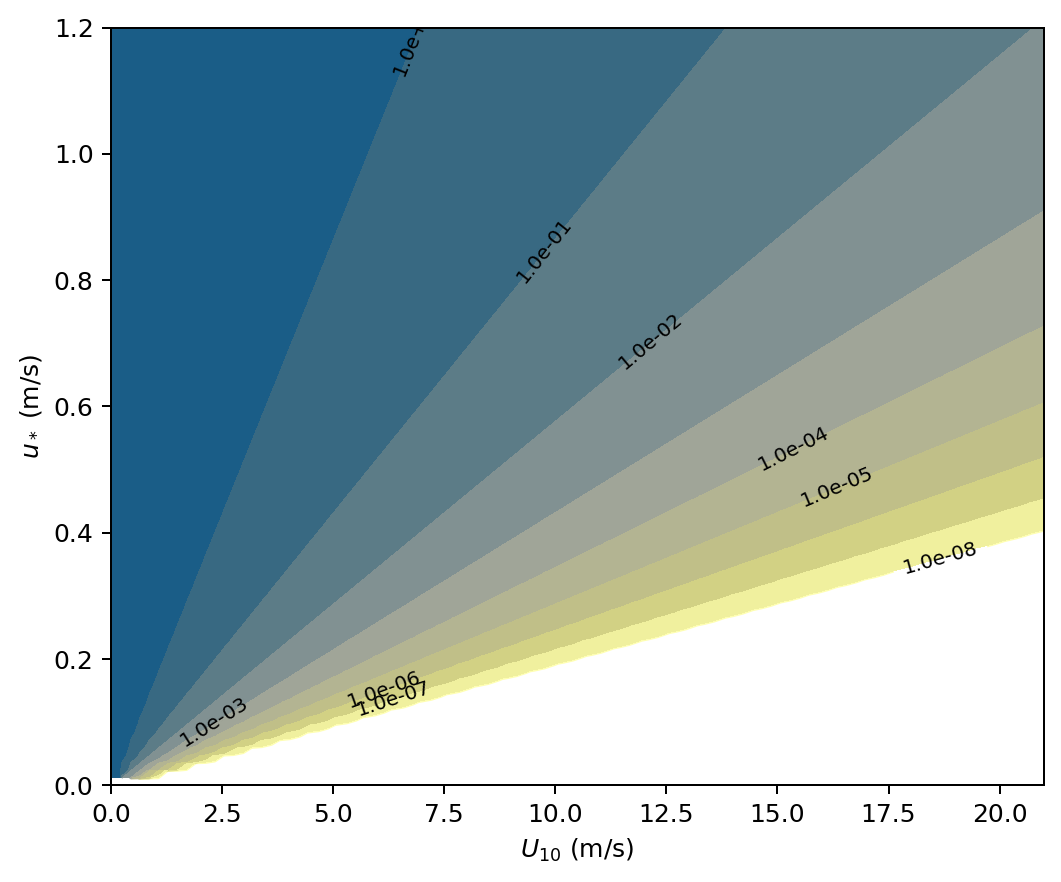

In [26]:
xlim = (0, 21)
ylim = (0, 1.2)

# ~ to check against aspect ratio in Edson et al
# fig, ax = coare_plot_starter(figsize=(12,4.85))

# ~  z0 contours under edson, coare, romero
# fig, ax = coare_plot_starter(figsize=(6,5))
# coare_color_by_z0(ax, xlim, ylim)

# ~ just z0 contours
coare_color_by_z0(False, xlim, ylim)


# Compare Equilibrium vs. JONSWAP in LES (using NGA)

### $H_s$ = 0.4 m

In [42]:
case_info = pd.read_excel('les_data/sf_case_log.xlsx', sheet_name='bl_coare_sweep', header=1, index_col=0)

cases = ['U18_HS04_kp07', 'HS04_js', 'HS04_js_match']
ids = ['Equilibrium', 'JONSWAP naive', 'JONSWAP matched']
colors = ['black', 'mediumseagreen', 'dodgerblue']

ids = ['Sp A '+id for id in ids]

caseids = [case+'/'+case for case in cases]

statlist = make_statlist(caseids, ids, case_info)

U(150) for Sp A Equilibrium: 16.49
U(150) for Sp A JONSWAP naive: 16.53
U(150) for Sp A JONSWAP matched: 16.68


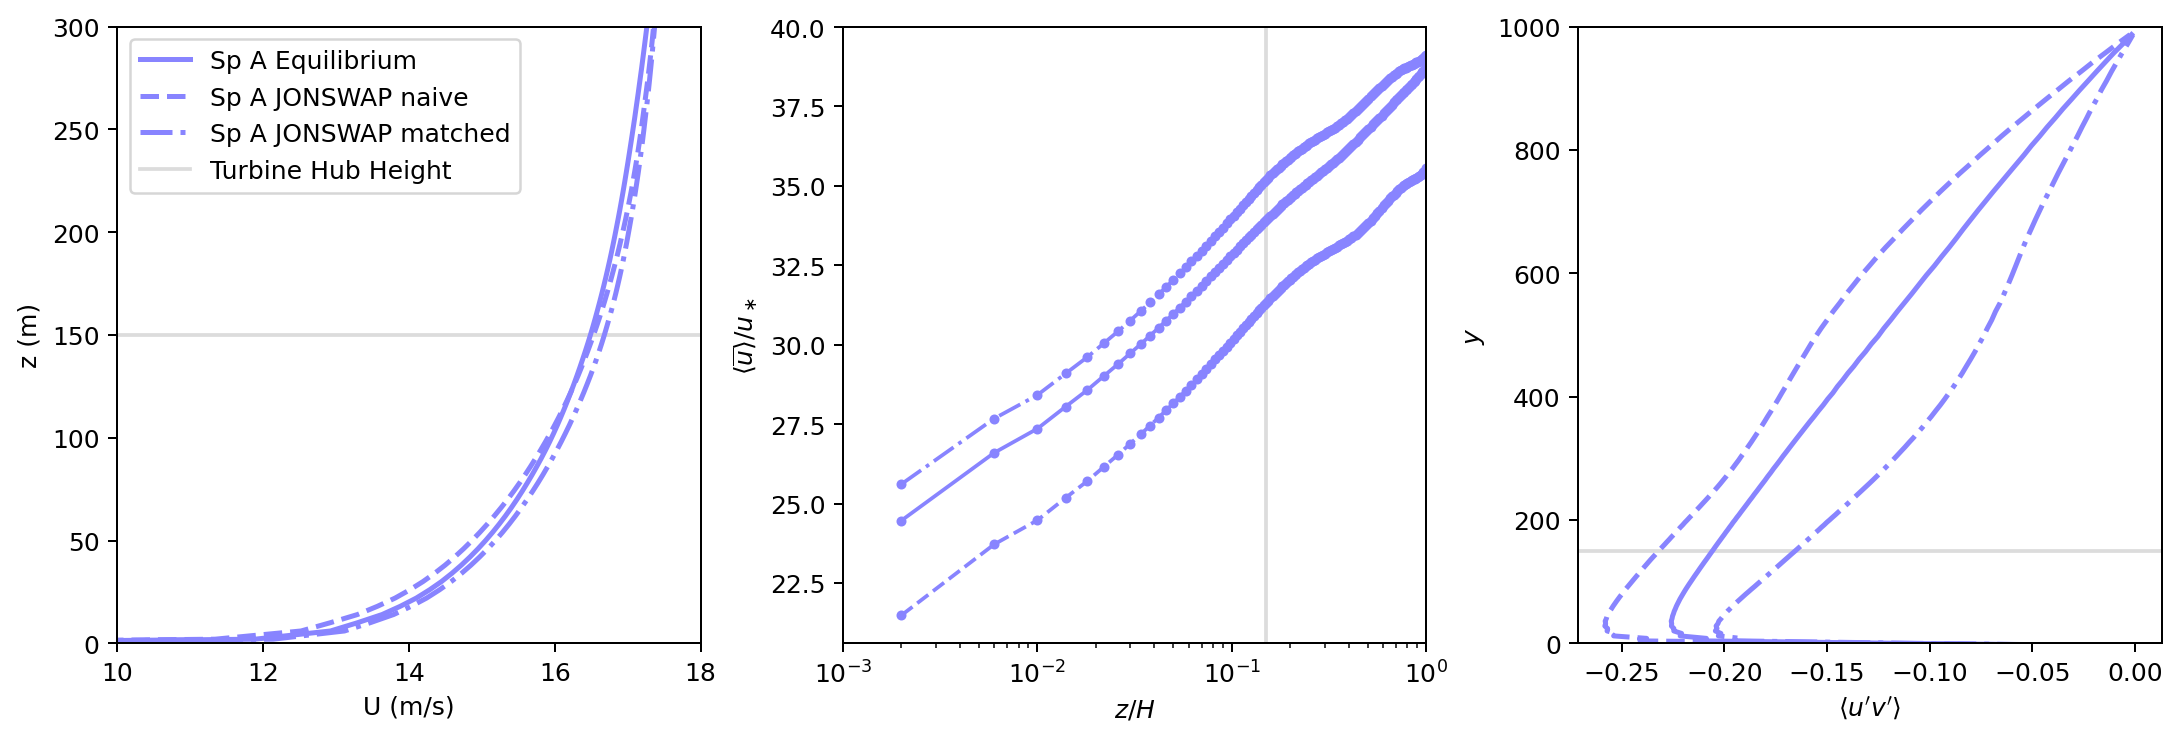

In [ ]:
fig, axs = plt.subplots(1,3,facecolor='w', dpi=180.0, figsize=(12,4))

labels = ['Equilibrium', 'JONSWAP from algorithm', 'JONSWAP matched energy']
colors = ['#8884FF' for i in range(len(ids))]

# print(axs[0:2])

plot_velocity(statlist, ids, colors, 
              axs=axs[0:2], labels=labels,
              linestyles=['-','--','-.'],
              )

plot_upvp(statlist, ids, colors, ax=axs[2], labels=False,
          linestyles=['-','--','-.'])

fig.set_constrained_layout(True)
fig.savefig('figures/Hs04_profiles.pdf')

/tmp/ipykernel_1244540/1769906107.py:26: RuntimeWarning: invalid value encountered in sqrt
  plt.scatter(ed['U10Nalex'], np.sqrt(ed['TAUalex']), s=10, marker='x', lw=1,


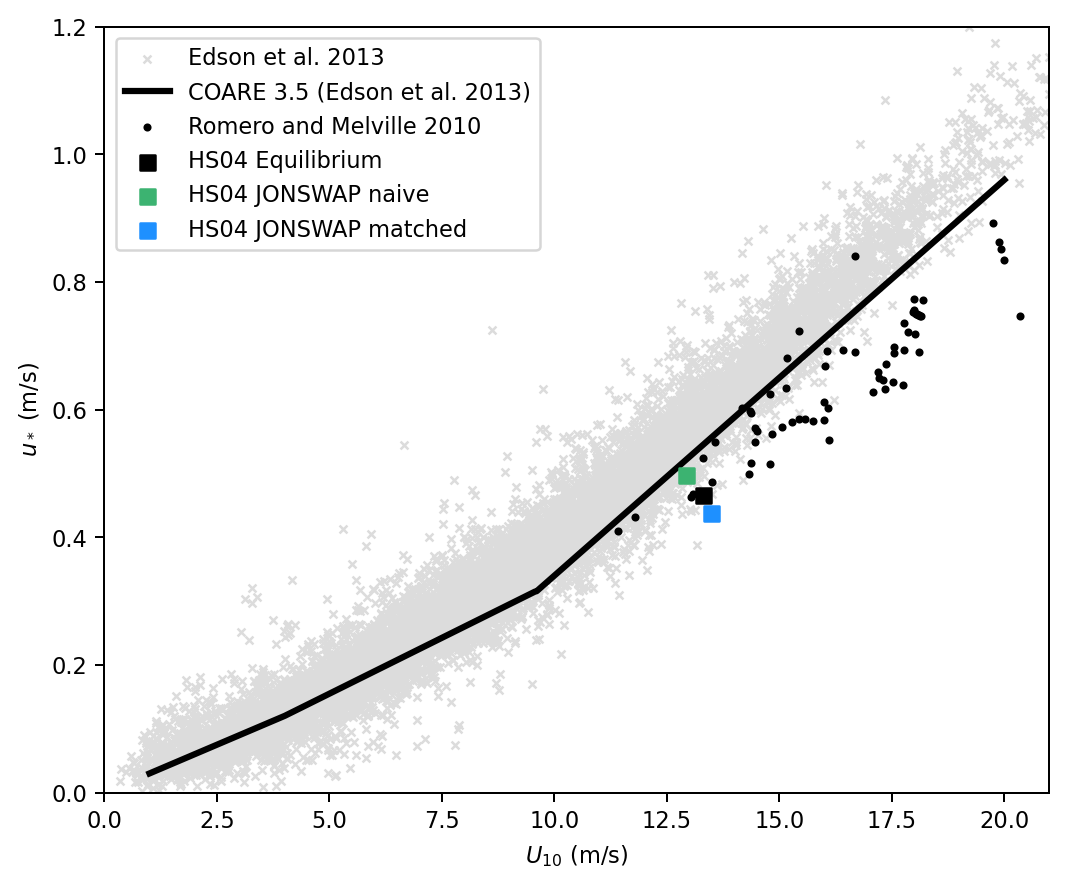

In [ ]:
rcParams.update({'font.size': 9})
z_us = [2,100]

fig, ax = coare_plot_starter(figsize=(6,5))

hs04_ustars = [stat.flux_ustar(z_us) for stat in statlist.values()]
hs04_u10s = [stat.Uz(10) for stat in statlist.values()]

for i in range(len(statlist)):
    ax.scatter(hs04_u10s[i], hs04_ustars[i], c=colors[i], marker='s',
               label=ids[i], zorder=3)

ax.legend()

### $k_p$ = 0.0393 m $^{-1}$

In [ ]:
case_info = pd.read_excel('les_data/sf_case_log.xlsx', sheet_name='bl_coare_sweep', header=1, index_col=0)

cases = ['U18_HS12_kp04', 'kp04_js', 'kp04_js_match']
ids = ['Equilibrium', 'JONSWAP naive', 'JONSWAP matched']

ids = ['Sp B '+id for id in ids]

caseids = [case+'/'+case for case in cases]

statlist = make_statlist(caseids, ids, case_info)

U(150) for Sp B Equilibrium: 16.03
U(150) for Sp B JONSWAP naive: 16.34
U(150) for Sp B JONSWAP matched: 16.23


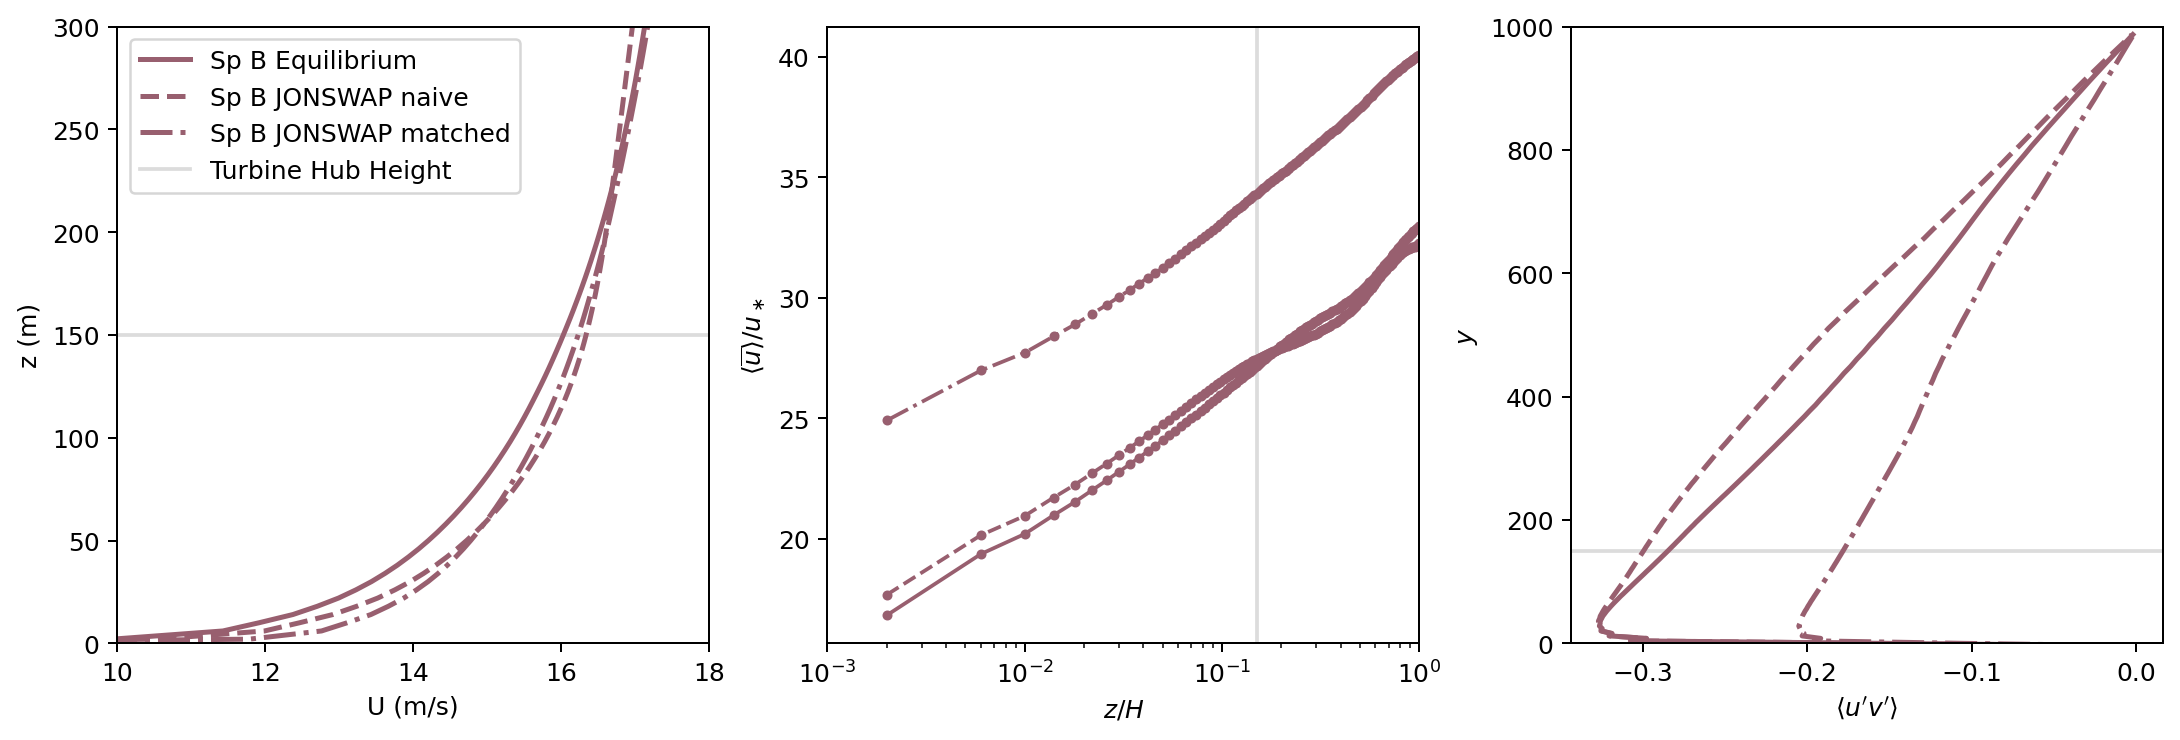

In [40]:
fig, axs = plt.subplots(1,3,facecolor='w', dpi=180.0, tight_layout=True, figsize=(12,4))

labels = ['Equilibrium', 'JONSWAP from algorithm', 'JONSWAP matched energy']
colors = ['#985F6F' for i in range(len(ids))]

plot_velocity(statlist, ids, colors, 
              axs=axs[0:2], labels=labels,
              linestyles=['-','--','-.'],
              )

plot_upvp(statlist, ids, colors, ax=axs[2], labels=False,
          linestyles=['-','--','-.'])

fig.set_constrained_layout(True)
fig.savefig('figures/kp04_profiles.pdf')

/tmp/ipykernel_1244540/1769906107.py:26: RuntimeWarning: invalid value encountered in sqrt
  plt.scatter(ed['U10Nalex'], np.sqrt(ed['TAUalex']), s=10, marker='x', lw=1,


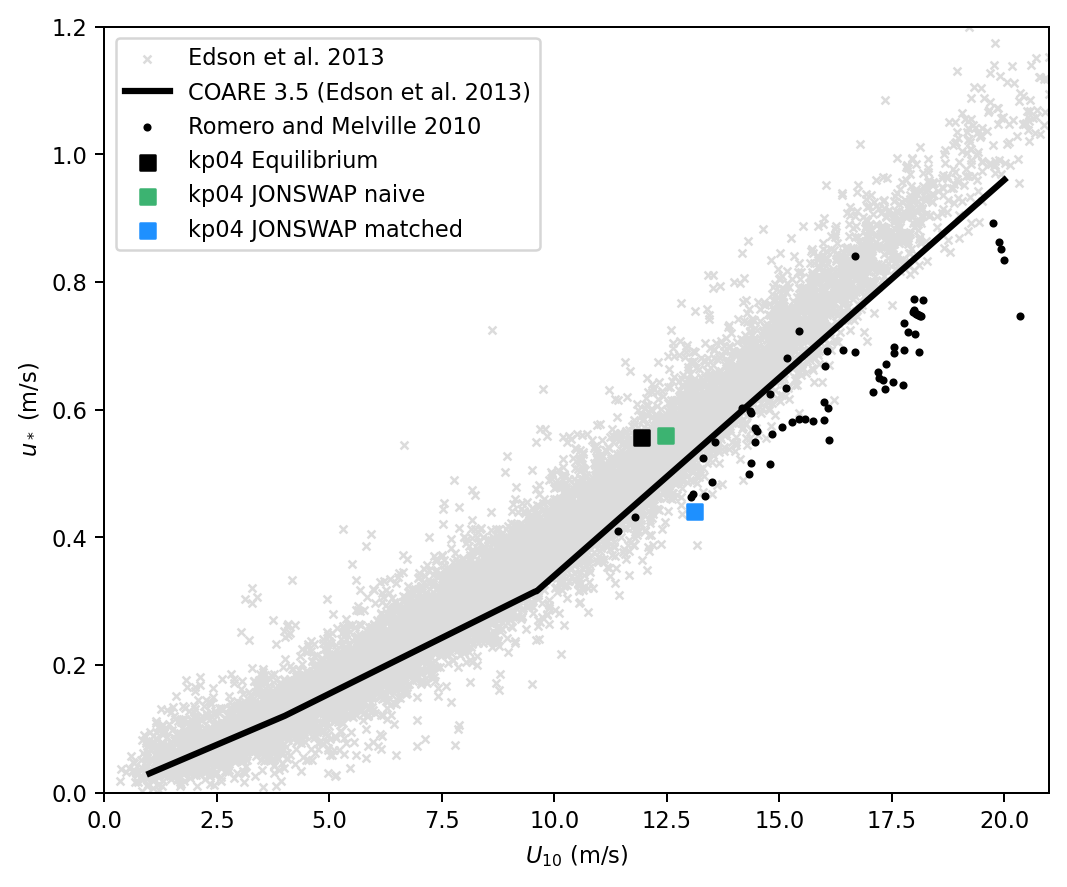

In [ ]:
rcParams.update({'font.size': 9})
z_us = [2,100]

fig, ax = coare_plot_starter(figsize=(6,5))

hs04_ustars = [stat.flux_ustar(z_us) for stat in statlist.values()]
hs04_u10s = [stat.Uz(10) for stat in statlist.values()]

for i in range(len(statlist)):
    ax.scatter(hs04_u10s[i], hs04_ustars[i], c=colors[i], marker='s',
               label=ids[i], zorder=3)

ax.legend()

### together

In [8]:
case_info = pd.read_excel('les_data/sf_case_log.xlsx', sheet_name='bl_coare_sweep', header=1, index_col=0)

U18cases = ['U18_HS04_kp07_swell', 'HS04_js', 'HS04_js_match',
        'U18_HS12_kp04_swell', 'kp04_js', 'kp04_js_match',
        'U18_HS20_kp07_swell', 'HS20_js', 'HS20_js_match',
        'U18_HS12_kp16_swell', 'kp16_js', 'kp16_js_match']
U_ids = ['Hs04 Equilibrium', 'Hs04 JONSWAP naive', 'Hs04 JONSWAP matched',
       'kp04 Equilibrium', 'kp04 JONSWAP naive', 'kp04 JONSWAP matched',
       'Hs12 Equilibrium', 'Hs12 JONSWAP naive', 'Hs12 JONSWAP matched',
       'kp16 Equilibrium', 'kp16 JONSWAP naive', 'kp16 JONSWAP matched']

U_cases = ['HS04_kp07_swell', 'HS04_js', 'HS04_js_match',
        'HS12_kp04_swell', 'kp04_js', 'kp04_js_match',
        'HS20_kp07_swell', 'HS20_js', 'HS20_js_match',
        'HS12_kp16_swell', 'kp16_js', 'kp16_js_match']

U24cases = ['U24_'+cname for cname in U_cases]
U24ids = ['U24 '+idname for idname in U_ids]

U12cases = ['U12_'+cname for cname in U_cases]
U12ids = ['U12 '+idname for idname in U_ids]

U18ids = ['U18 '+idname for idname in U_ids]

cases = U12cases + U18cases + U24cases
ids = U12ids + U18ids + U24ids

# cases = ['U18_HS20_kp07_swell', 'HS20_js', 'HS20_js_match',
#         'U18_HS12_kp16_swell', 'kp16_js', 'kp16_js_match',
#        #  'U18_HS04_kp07_swell', 'HS04_js', 'HS04_js_match',
#        #  'U18_HS12_kp04_swell', 'kp04_js', 'kp04_js_match',
#         ]
# ids = ['Hs12 Equilibrium', 'Hs12 JONSWAP naive', 'Hs12 JONSWAP matched',
#        'kp16 Equilibrium', 'kp16 JONSWAP naive', 'kp16 JONSWAP matched',
#        # 'Hs04 Equilibrium', 'Hs04 JONSWAP naive', 'Hs04 JONSWAP matched',
#        # 'kp04 Equilibrium', 'kp04 JONSWAP naive', 'kp04 JONSWAP matched',
       # ]

caseids = [case+'/'+case for case in cases]

statlist = make_statlist(caseids, ids, case_info)


/tmp/ipykernel_1899059/3546264435.py:26: RuntimeWarning: invalid value encountered in sqrt
  plt.scatter(ed['U10Nalex'], np.sqrt(ed['TAUalex']/1.2), s=8, marker='x', lw=0.5,


Text(0.7, 0.35, '$U_0$ = 24 m/s')

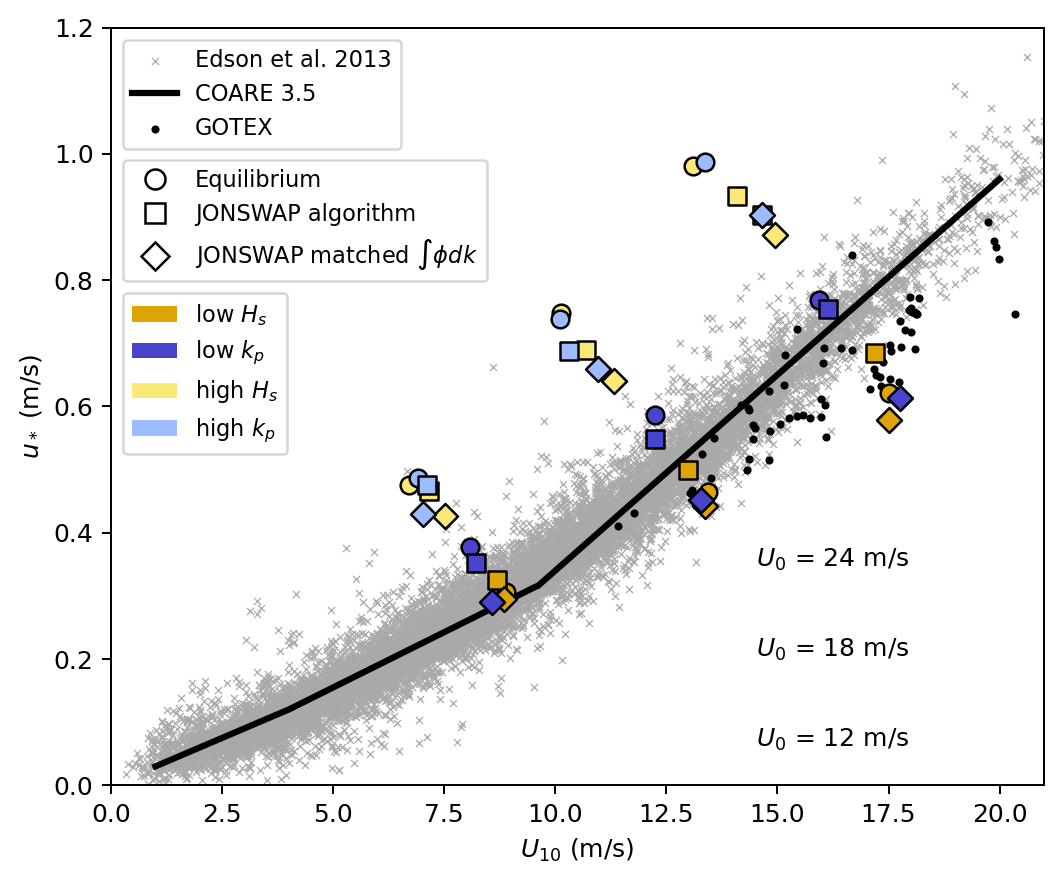

In [9]:
rcParams.update({'font.size': 10})
z_us = [0,100]

fig, ax = coare_plot_starter(figsize=(6,5))

ustars = [stat.flux_ustar(z_us) for stat in statlist.values()]
# ustars = [stat.ustar for stat in statlist.values()]
u10s = [stat.Uz(10) for stat in statlist.values()]
 
# colors = ['#8884FF', '#985F6F', 'dodgerblue', 'crimson']
# colors = ['#294D4A', '#776472', '#A799B7', '#AEC3B0']
colors = ['#DEA404', '#4844CB', '#FAE877', '#9CBCFF']
# markers = ['s', '^', 'v']
markers = ['o', 's', 'D']

colors = colors + colors + colors

for i in range(len(statlist)):
    ax.scatter(u10s[i], ustars[i], c=colors[int(i/3)], marker=markers[i%3],
               zorder=3, edgecolor='black', s=50)

# * build legend
# shape_labels = ['Equilibrium', 'JONSWAP \nfrom algorithm', 'JONSWAP \nmatched energy']
shape_labels = ['Equilibrium', 'JONSWAP algorithm', r'JONSWAP matched $\int\phi dk$']
shape_handles = [
    Line2D([0], [0], marker=m, color='k', markerfacecolor='white',
           linestyle='None', markersize=8)
    for m in markers ]
# color_labels = ['Spectrum A', 'Spectrum B']
# color_labels = ['HS04', 'kp04', 'HS20', 'kp16']
# color_labels = [r'$H_S = 0.4$m, $k_p = 0.0785$m$^{-1}$',
#                 r'$H_S = 1.2$m, $k_p = 0.0393$m$^{-1}$', 
#                 r'$H_S = 2.0$m, $k_p = 0.0785$m$^{-1}$', 
#                 r'$H_S = 1.2$m, $k_p = 0.157$m$^{-1}$']
color_labels = [r'low $H_s$',# ($H_sk_p$=0.031)',
                r'low $k_p$',# ($H_sk_p$=0.047)',
                r'high $H_s$',# ($H_sk_p$=0.157)',
                r'high $k_p$',# ($H_sk_p$=0.188)']
]
color_handles = [
    Patch(facecolor=c, edgecolor='none')
    for c in colors ]

handles, labels = ax.get_legend_handles_labels()
# handles += shape_handles
# labels += shape_labels
# handles += color_handles
# labels += color_labels
# ax.legend(handles, labels, fontsize=9)


leg1 = ax.legend(handles, labels, fontsize=9,
                 loc="upper left",
                 bbox_to_anchor=(0.001, 0.999))
leg2 = ax.legend(shape_handles, shape_labels, fontsize=9,
                 loc="upper left",
                 bbox_to_anchor=(0.001, 0.84))
leg3 = ax.legend(color_handles, color_labels, fontsize=9,
                 loc="upper left",
                 bbox_to_anchor=(0.001, 0.665))

ax.add_artist(leg1)
ax.add_artist(leg2)

ax.annotate(r'$U_0$ = 12 m/s', (0.7, 0.15), xycoords='figure fraction')
ax.annotate(r'$U_0$ = 18 m/s', (0.7, 0.25), xycoords='figure fraction')
ax.annotate(r'$U_0$ = 24 m/s', (0.7, 0.35), xycoords='figure fraction')


# ax.set_ylim((0.2,1.2))
# ax.set_xlim((5,21))

# ax.set_ylim((0.6, 0.9))
# ax.set_xlim((9,11))

# fig.savefig('figures/les_comparison.pdf')

In [25]:
def wavecase_statlist(cases, label):
    case_info = pd.read_excel('les_data/sf_case_log.xlsx', sheet_name='bl_coare_sweep', header=1, index_col=0)

    ids = ['Equilibrium', 'JONSWAP \nfrom algorithm', 'JONSWAP \nmatched energy']
    ids = [label+' '+id for id in ids]

    caseids = [case+'/'+case for case in cases]
    statlist = make_statlist(caseids, ids, case_info)

    return statlist, ids

In [32]:
def plot_wave_profiles(statlist, ids, axs, color, xlabel=False):
    ls = ['-','--','-.']
    colors = [color for i in range(len(ids))]

    plot_velocity(statlist, ids, colors, 
              axs=axs[0:2], labels=True,
              linestyles=ls, xlabel=xlabel,
              )
    
    print('')

    plot_upvp(statlist, ids, colors, ax=axs[2], labels=False, xlabel=xlabel,
          linestyles=ls)
    
    plot_tke(statlist, ids, colors, ax=axs[3], labels=False, xlabel=xlabel,
          linestyles=ls)




In [26]:

hs04_statlist, hs04_ids = wavecase_statlist(
    ['U18_HS04_kp07_swell', 'HS04_js', 'HS04_js_match'],
    'HS04'
    )

kp04_statlist, kp04_ids = wavecase_statlist(
    ['U18_HS12_kp04_swell', 'kp04_js', 'kp04_js_match'],
    'kp04')


hs20_statlist, hs20_ids = wavecase_statlist(
    ['U18_HS20_kp07_swell', 'HS20_js', 'HS20_js_match'],
    'HS20')

kp16_statlist, kp16_ids = wavecase_statlist(
    ['U18_HS12_kp16_swell', 'kp16_js', 'kp16_js_match'],
    'kp16')

In [ ]:
z1 = 150-240/2
z2 = 150+240/2

allstats = {**hs04_statlist, **kp04_statlist}

print('Power difference for average velocity across rotor')
print('--------------------------------------------------\n')

for id in hs04_ids + kp04_ids:
    stat = allstats[id]
    Umean = stat.mean_Uz(z1, z2)
    print('<U> across rotor for '+id.replace("\n","").ljust(30)+': {:.3f}'.format(Umean))

print('\n--------------------------------------------------\n')
print('Spec A power difference 3.05%')
print('Spec B power difference 4.87%')

Power difference for average velocity across rotor
--------------------------------------------------

<U> across rotor for Spec A Equilibrium            : 16.311
<U> across rotor for Spec A JONSWAP from algorithm : 16.319
<U> across rotor for Spec A JONSWAP matched energy : 16.475
<U> across rotor for Spec B Equilibrium            : 15.835
<U> across rotor for Spec B JONSWAP from algorithm : 16.088
<U> across rotor for Spec B JONSWAP matched energy : 16.072

--------------------------------------------------

Spec A power difference 3.05%
Spec B power difference 4.87%


Power difference for average velocity at hub height
---------------------------------------------------

U(150) for HS04 Equilibrium              : 16.72
U(150) for HS04 JONSWAP from algorithm   : 16.50
U(150) for HS04 JONSWAP matched energy   : 16.48

U(150) for kp04 Equilibrium              : 16.28
U(150) for kp04 JONSWAP from algorithm   : 16.17
U(150) for kp04 JONSWAP matched energy   : 16.40

U(150) for HS20 Equilibrium              : 15.99
U(150) for HS20 JONSWAP from algorithm   : 15.75
U(150) for HS20 JONSWAP matched energy   : 15.94

U(150) for kp16 Equilibrium              : 15.87
U(150) for kp16 JONSWAP from algorithm   : 15.47
U(150) for kp16 JONSWAP matched energy   : 15.90


---------------------------------------------------

Spec A power difference 3.50%
Spec B power difference 5.91%


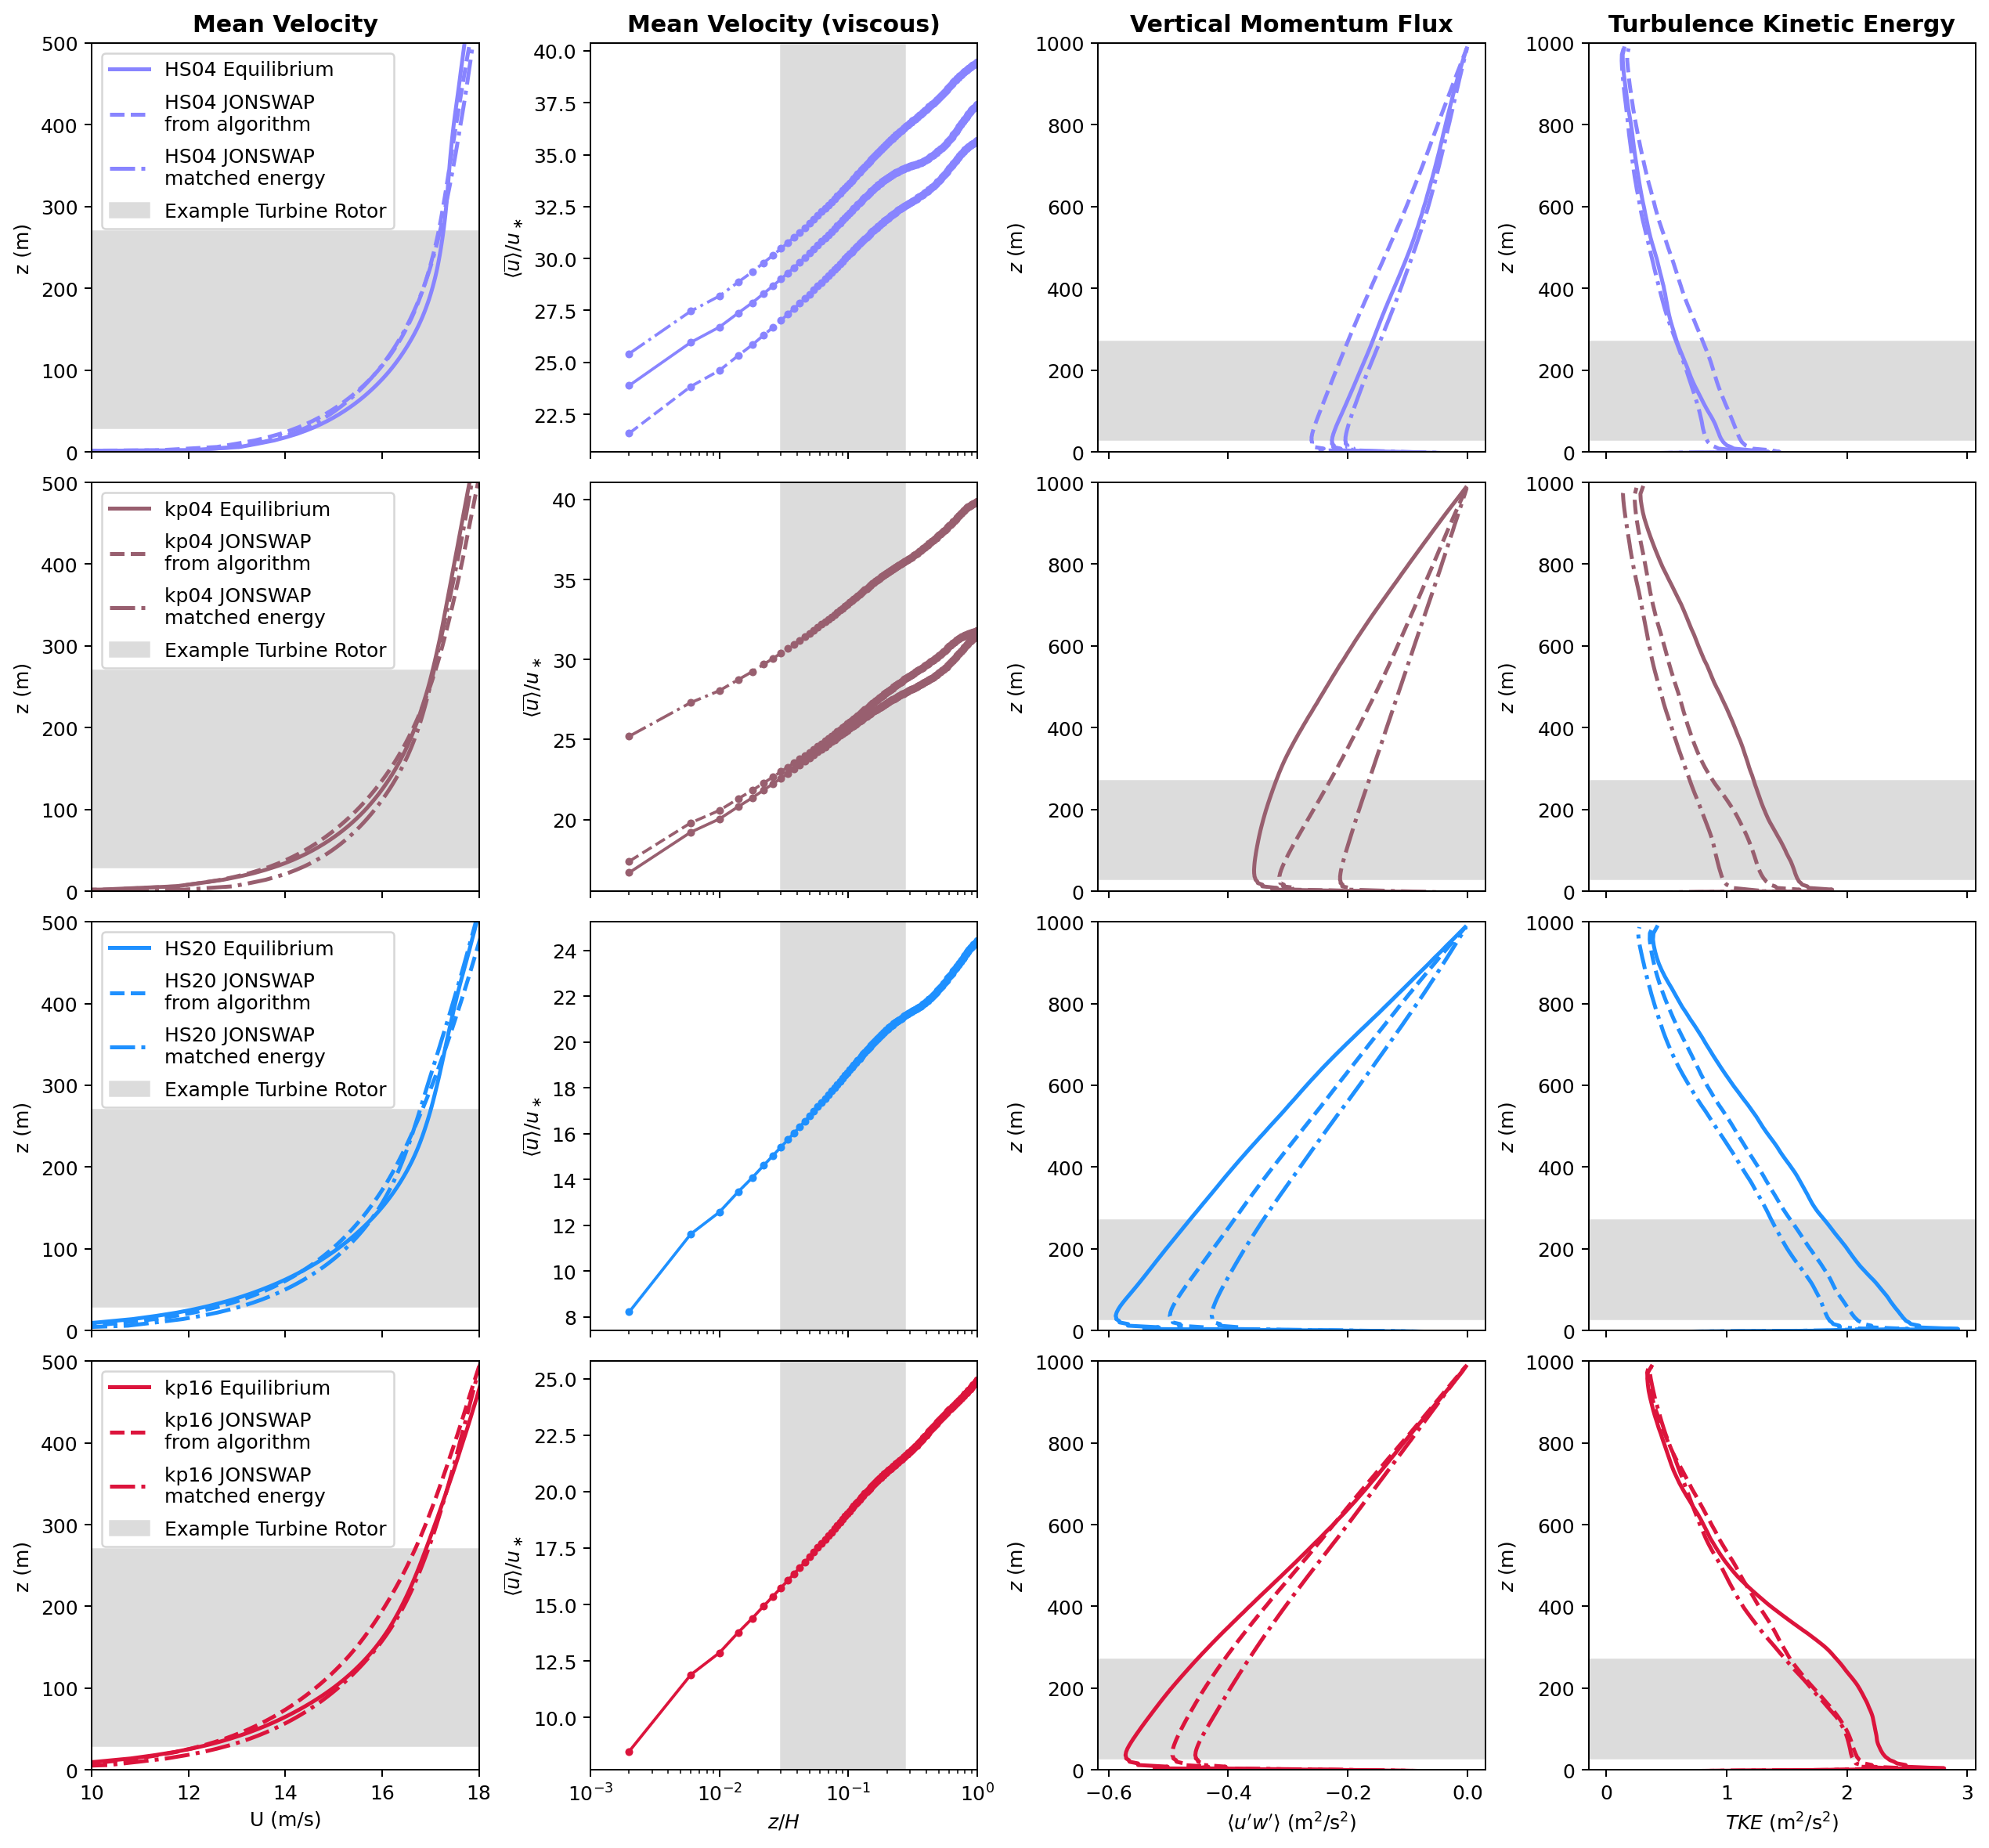

In [ ]:
fig, axs = plt.subplots(4,4,facecolor='w', dpi=180.0, figsize=(14,13), sharex='col')

print('Power difference for average velocity at hub height')
print('---------------------------------------------------\n')

plot_wave_profiles(hs04_statlist, hs04_ids, axs[0,:], '#8884FF')
plot_wave_profiles(kp04_statlist, kp04_ids, axs[1,:], '#985F6F')
plot_wave_profiles(hs20_statlist, hs20_ids, axs[2,:], 'dodgerblue')
plot_wave_profiles(kp16_statlist, kp16_ids, axs[3,:], 'crimson', xlabel=True)

fw = 'semibold'
axs[0,0].set_title('Mean Velocity', weight=fw)
axs[0,1].set_title('Mean Velocity (viscous)', weight=fw)
axs[0,2].set_title('Vertical Momentum Flux', weight=fw)
axs[0,3].set_title('Turbulence Kinetic Energy', weight=fw)

fig.set_constrained_layout(True)
# fig.savefig('figures/all_profiles.pdf')

print('\n---------------------------------------------------\n')
print('Spec A power difference 3.50%')
print('Spec B power difference 5.91%')

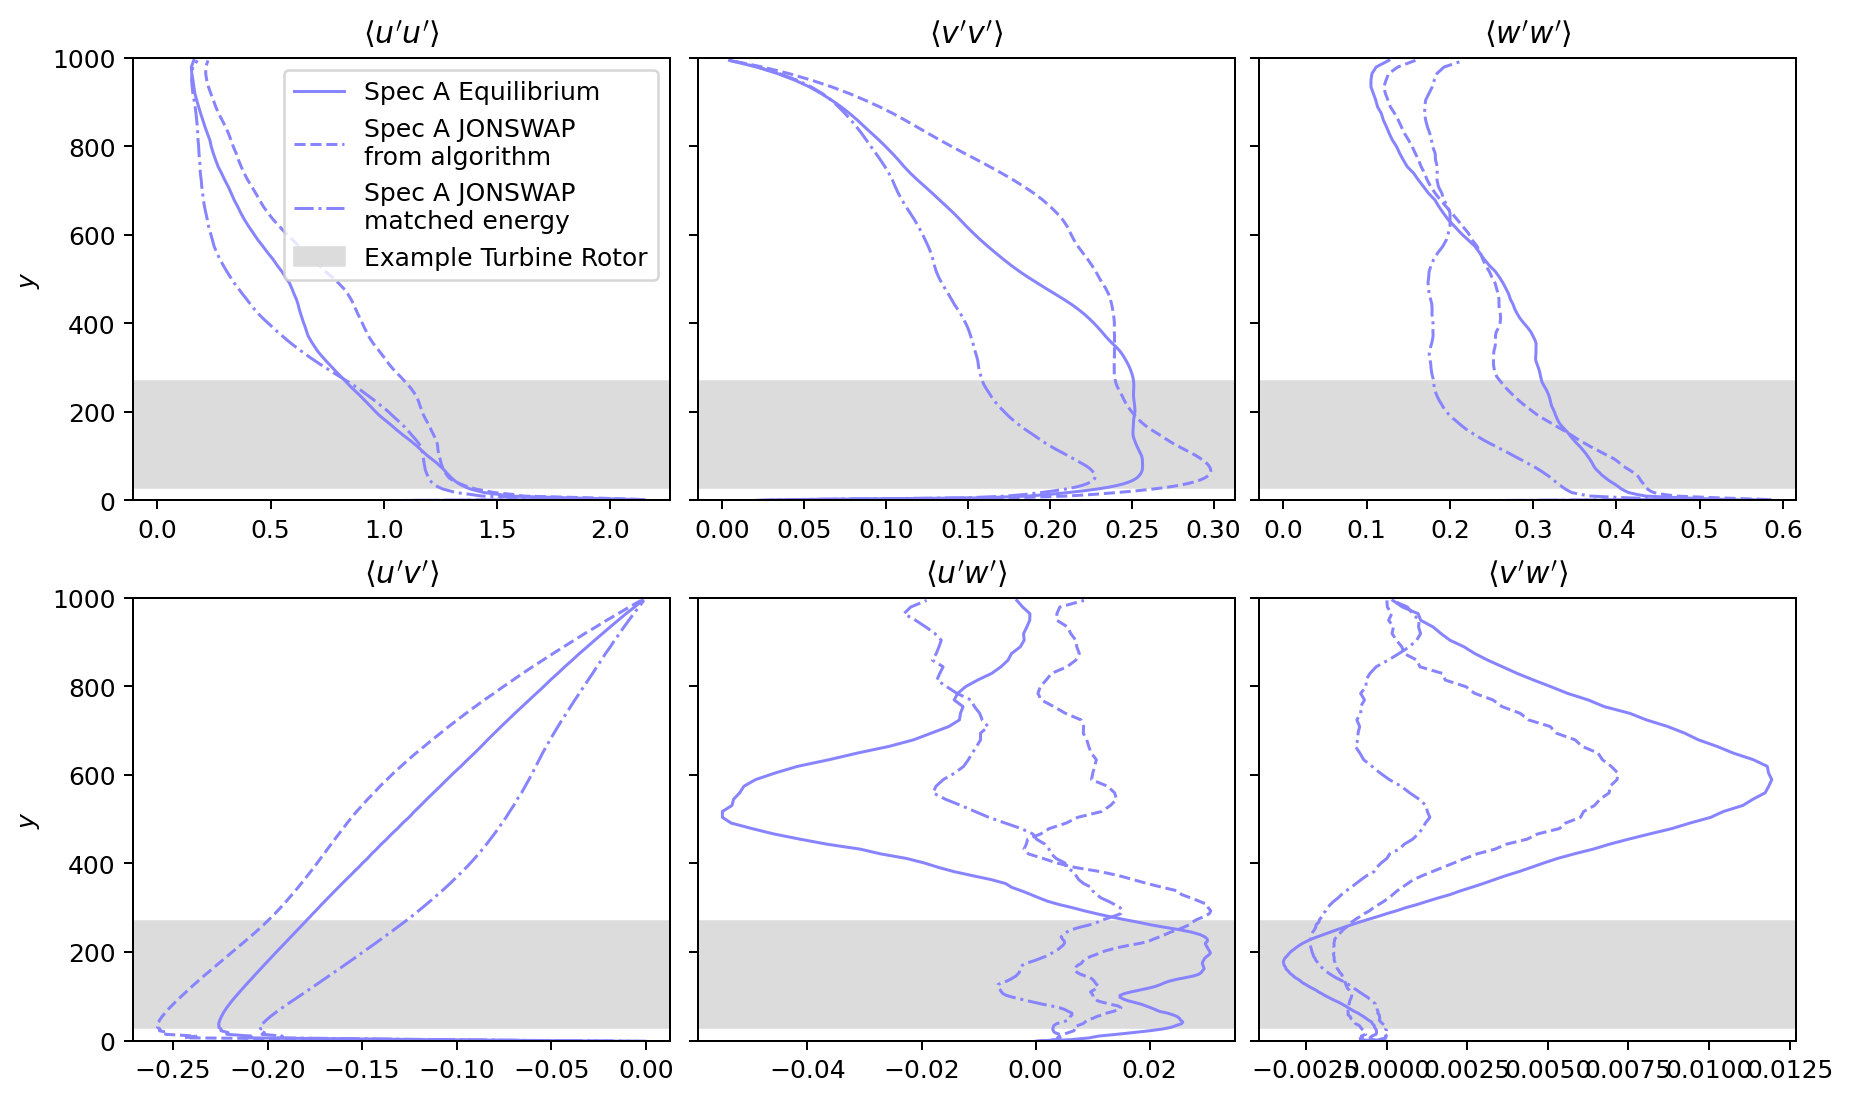

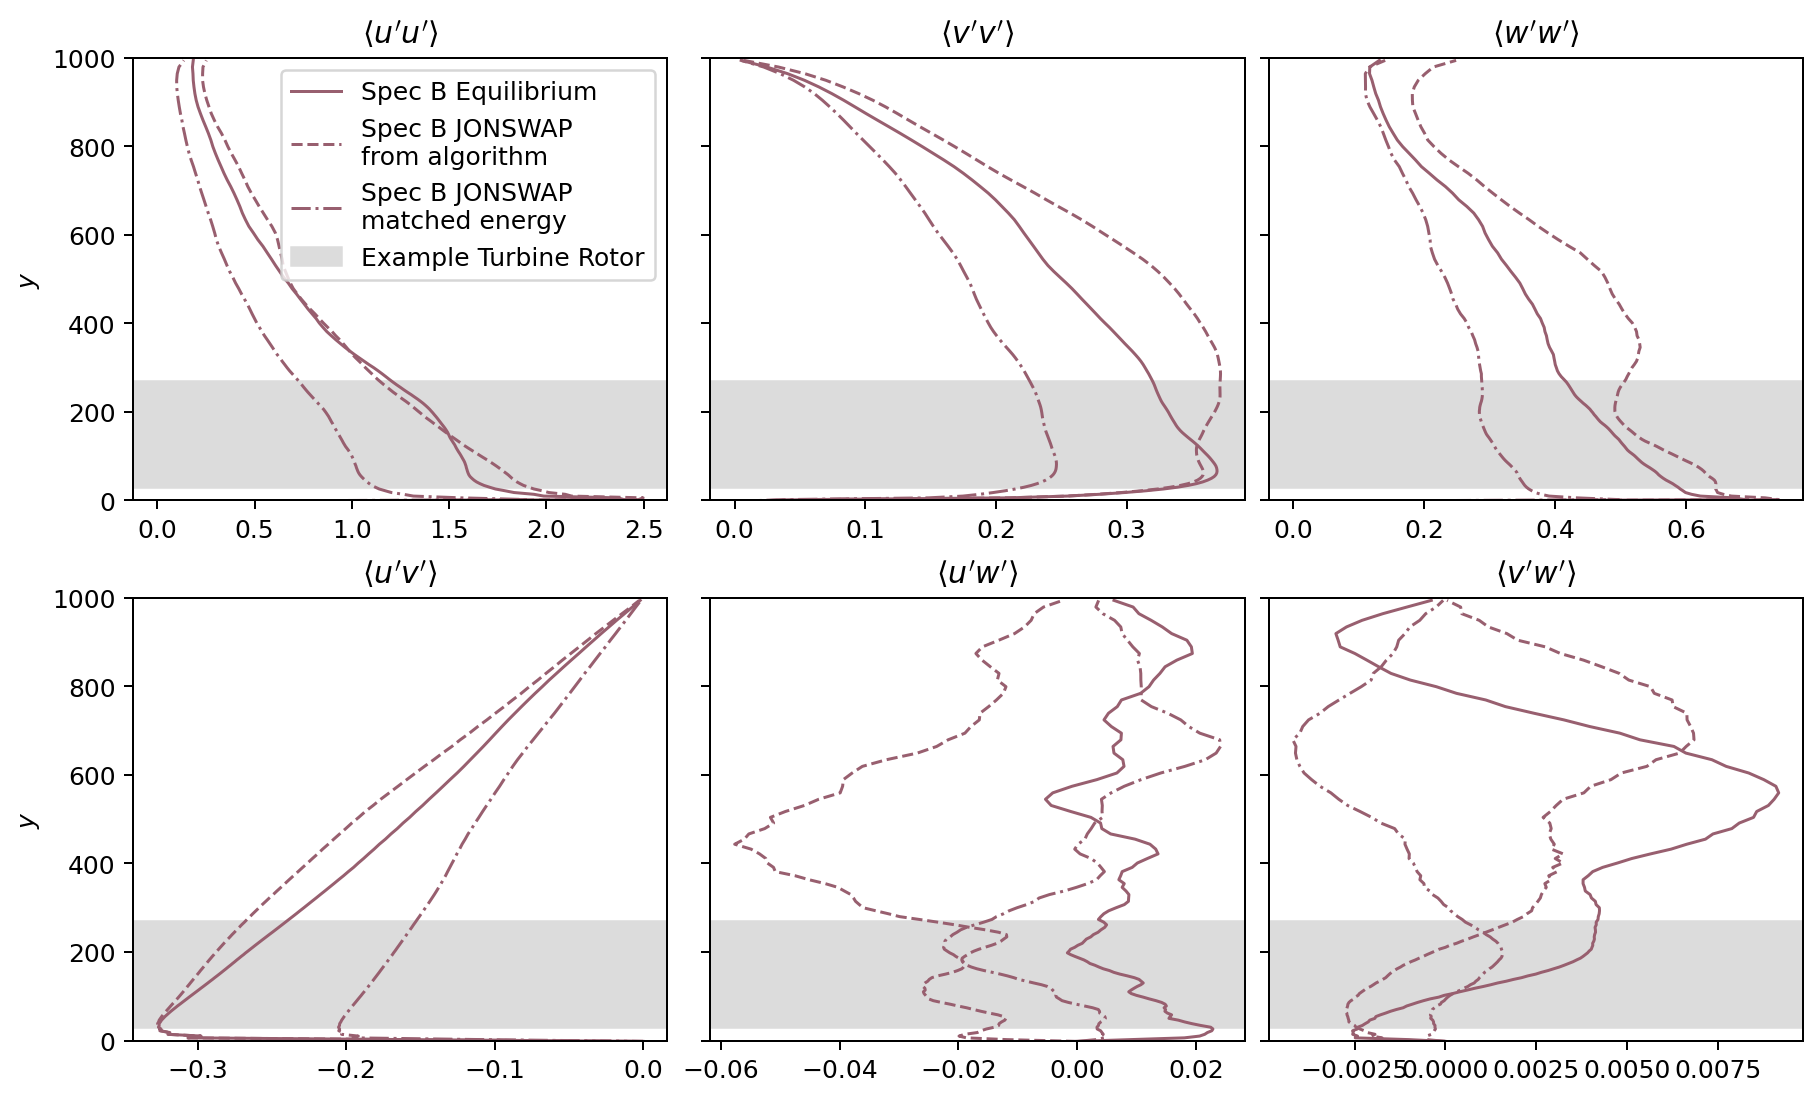

In [ ]:
plot_reynolds(hs04_statlist, hs04_ids, hs04_colors, linestyles=['-','--','-.'])

plot_reynolds(kp04_statlist, kp04_ids, kp04_colors, linestyles=['-','--','-.'])